In [2]:
import pandas as pd
df = pd.read_csv('rolling_stones_spotify.csv')
print(df.head())

   Unnamed: 0                         name               album release_date  \
0           0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10   
1           1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10   
2           2           Start Me Up - Live  Licked Live In NYC   2022-06-10   
3           3  If You Can't Rock Me - Live  Licked Live In NYC   2022-06-10   
4           4            Don’t Stop - Live  Licked Live In NYC   2022-06-10   

   track_number                      id                                   uri  \
0             1  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT   
1             2  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU   
2             3  1Lu761pZ0dBTGpzxaQoZNW  spotify:track:1Lu761pZ0dBTGpzxaQoZNW   
3             4  1agTQzOTUnGNggyckEqiDH  spotify:track:1agTQzOTUnGNggyckEqiDH   
4             5  7piGJR8YndQBQWVXv6KtQw  spotify:track:7piGJR8YndQBQWVXv6KtQw   

   acousticness  danceability  energy 

In [ ]:
#Initial data inspection and data cleaning:
#Check whether the data has duplicates, missing values, irrelevant (erroneous entries) values, or outliers.

Number of duplicates: 0
Missing values per column:
Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64


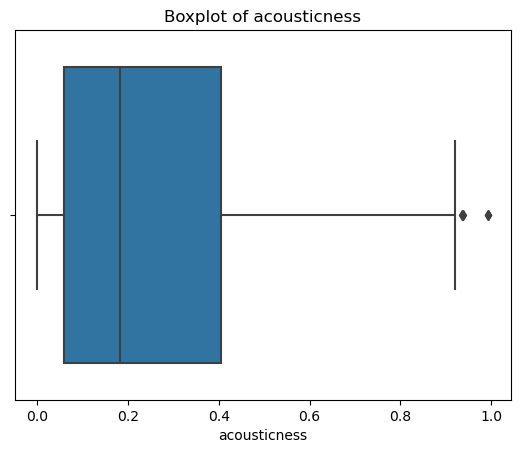

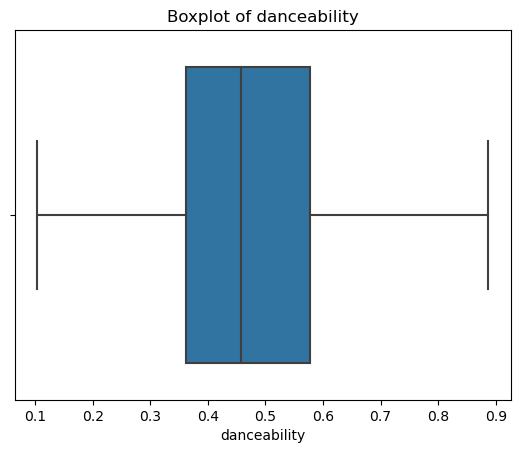

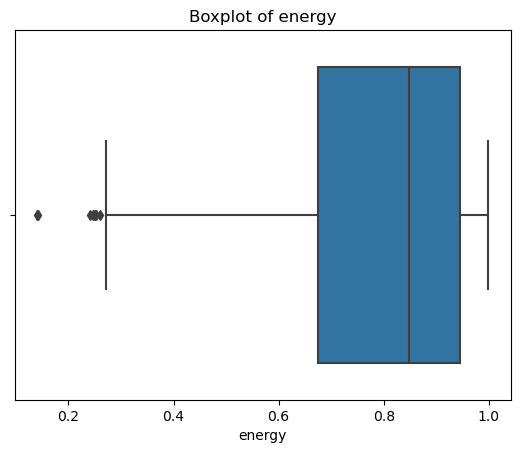

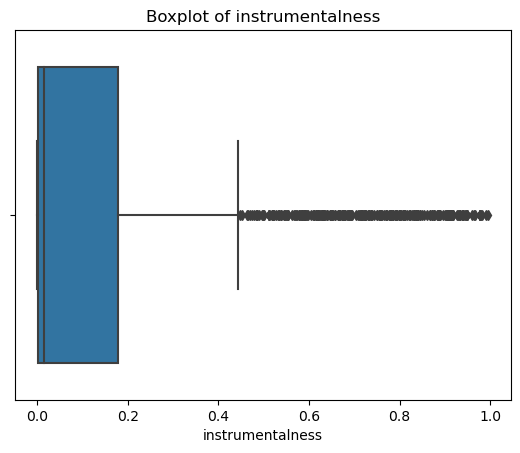

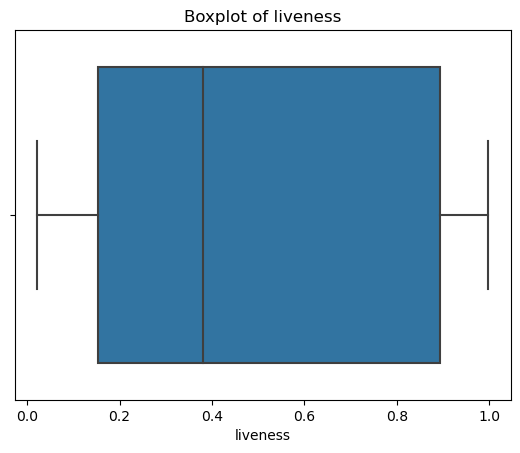

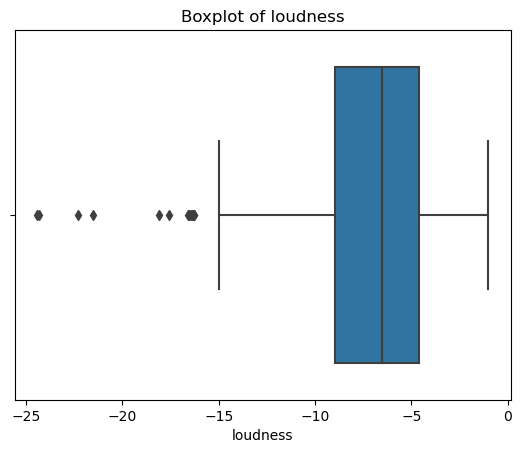

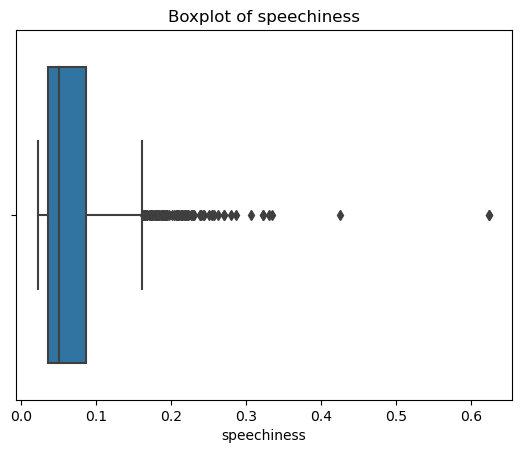

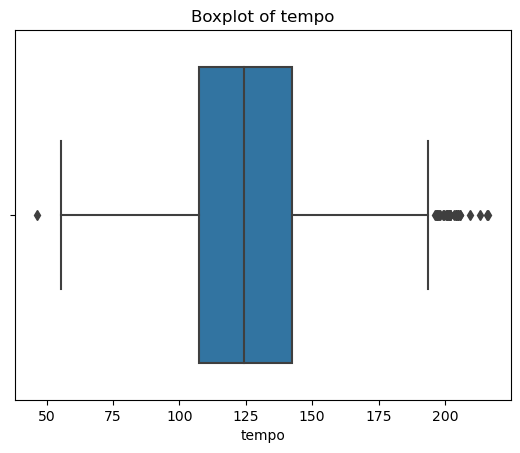

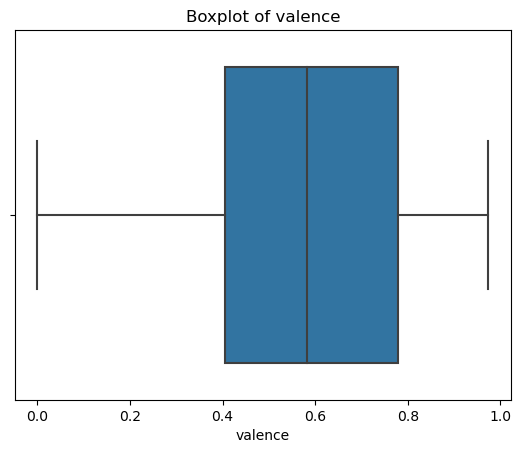

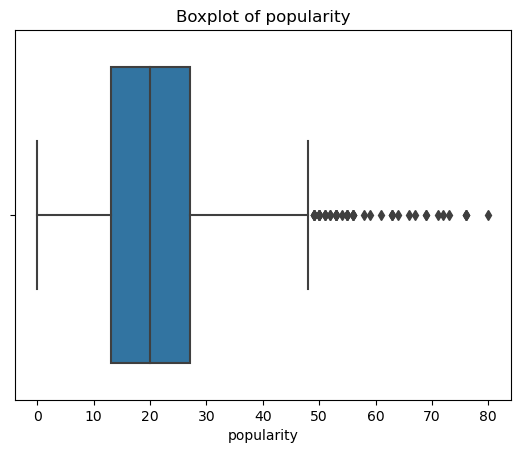

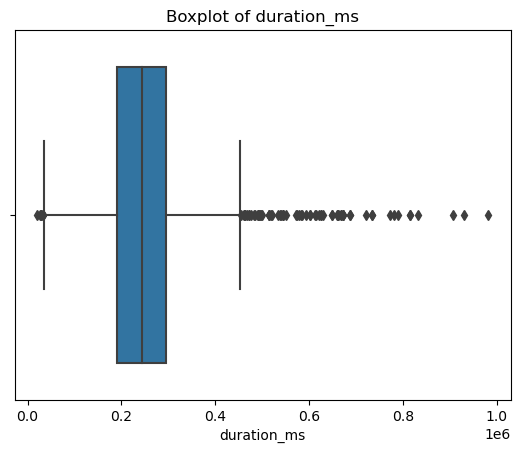

In [18]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('rolling_stones_spotify.csv')

duplicates = df.duplicated()
print("Number of duplicates:", duplicates.sum())

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']

for column in numerical_columns:
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()



In [ ]:
#Depending on your findings, clean the data for further processing.

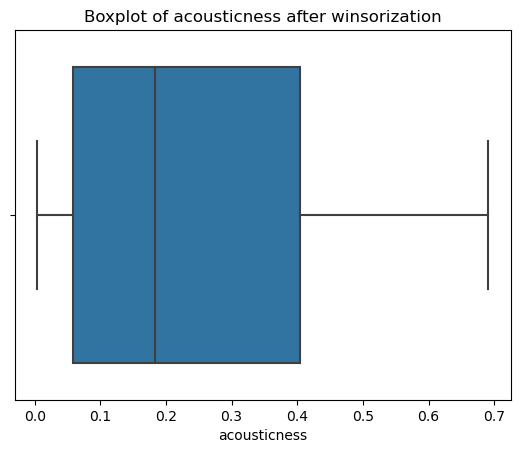

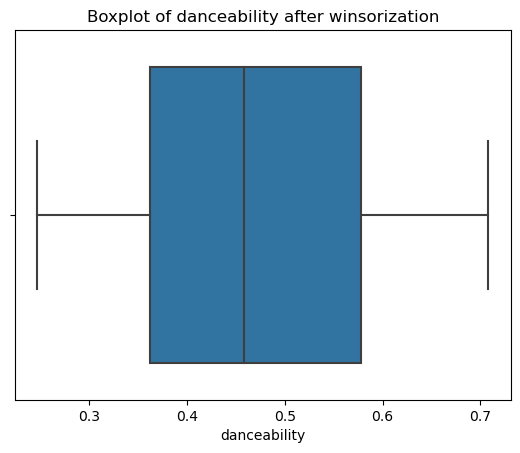

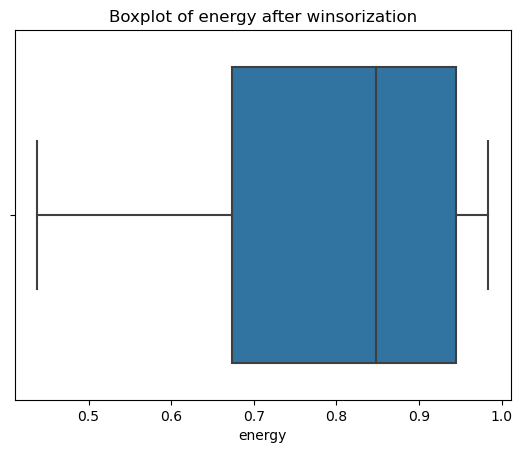

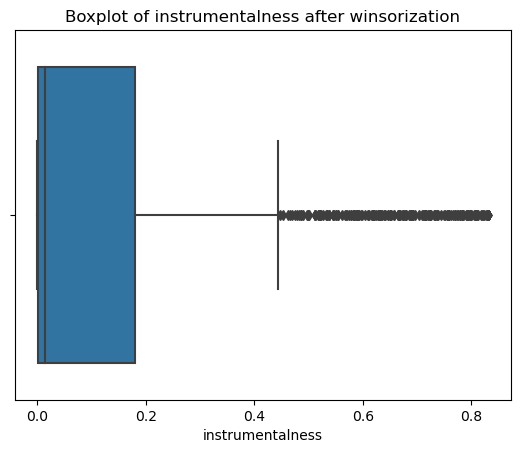

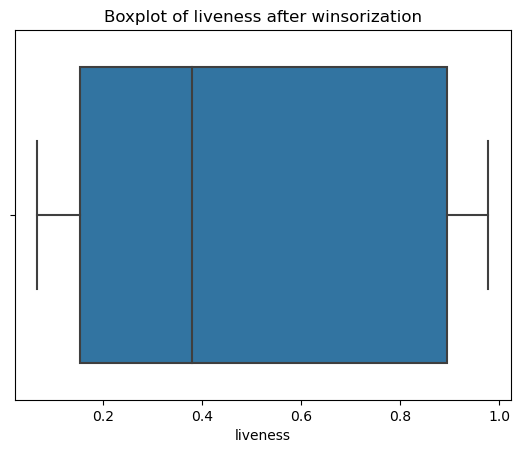

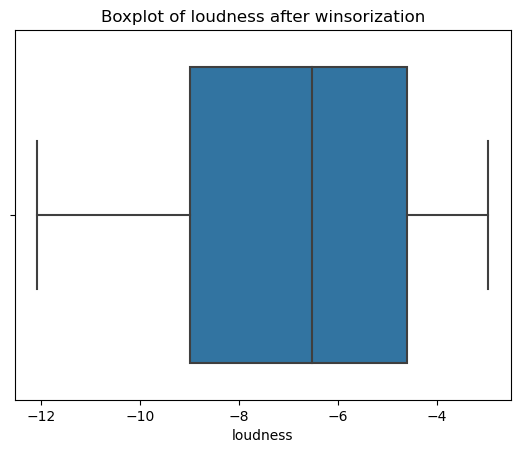

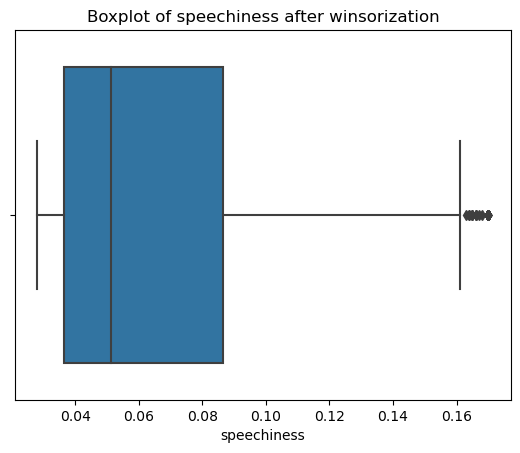

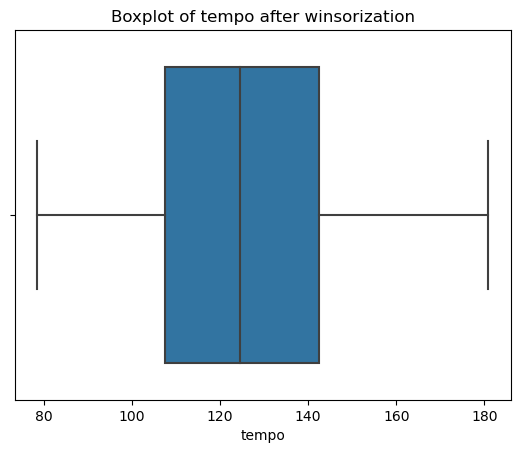

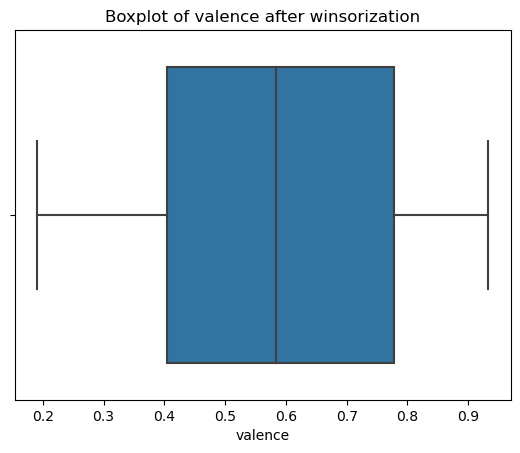

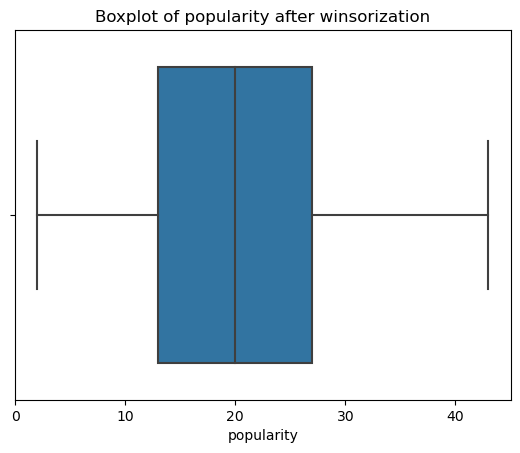

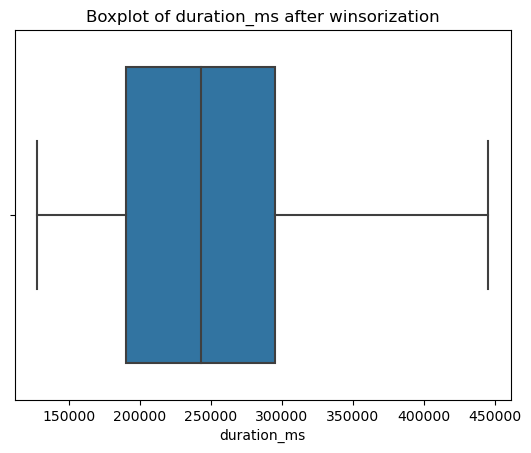

In [9]:
from scipy.stats.mstats import winsorize

numerical_columns = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']

for column in numerical_columns:
    winsorized_data = winsorize(df[column], limits=[0.05, 0.05])  
    df[column] = winsorized_data

for column in numerical_columns:
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column} after winsorization")
    plt.show()


In [ ]:
#Perform Exploratory Data Analysis and Feature Engineering:

#Use appropriate visualizations to find out which two albums should be recommended to anyone based on the number of popular songs in an album.
#Perform exploratory data analysis to dive deeper into different features of songs and identify the pattern.
#Discover how a song's popularity relates to various factors and how this has changed over time.
#Comment on the importance of dimensionality reduction techniques, share your ideas and explain your observations.


In [11]:
popularity_range = df['popularity'].describe()

print("Popularity Range for Each Song:")
print(popularity_range)


Popularity Range for Each Song:
count    1610.000000
mean       20.344720
std        11.033867
min         2.000000
25%        13.000000
50%        20.000000
75%        27.000000
max        43.000000
Name: popularity, dtype: float64


/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:4691: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


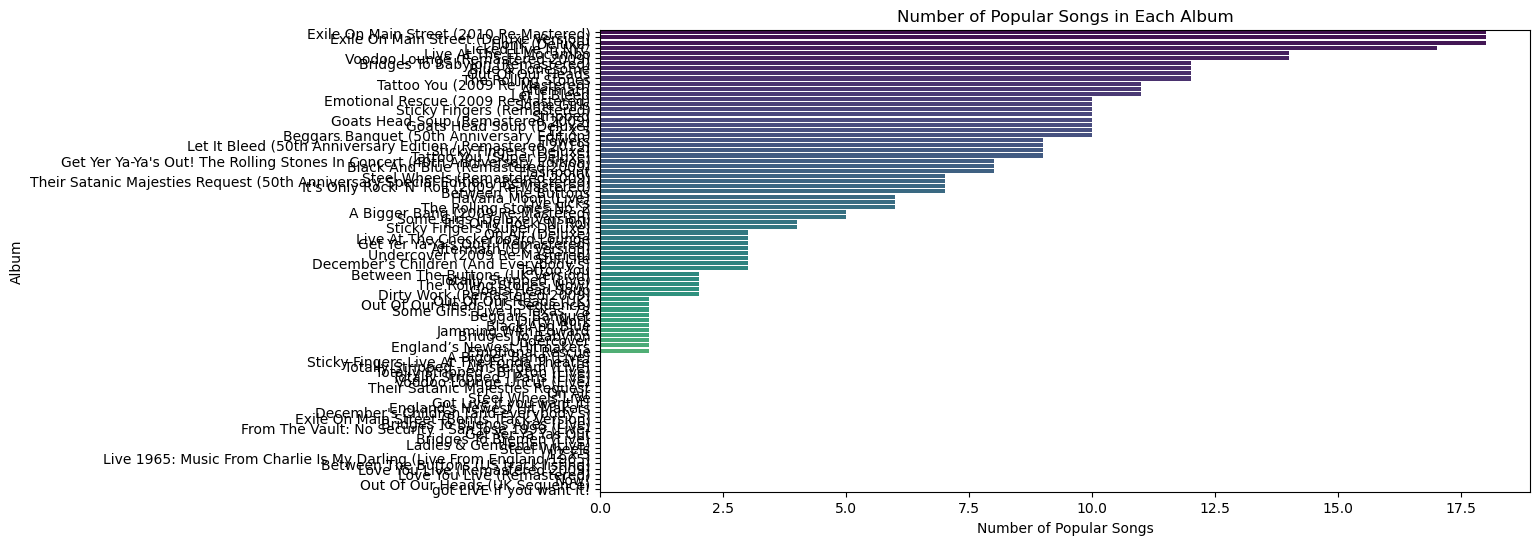

The recommended albums based on the number of popular songs are: Exile On Main Street (2010 Re-Mastered), Exile On Main Street (Deluxe Version)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

popularity_threshold = 27  # Using the 75th percentile as the popularity threshold

df['is_popular'] = df['popularity'] >= popularity_threshold
popular_songs_per_album = df.groupby('album')['is_popular'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=popular_songs_per_album.values, y=popular_songs_per_album.index, palette='viridis')
plt.xlabel('Number of Popular Songs')
plt.ylabel('Album')
plt.title('Number of Popular Songs in Each Album')
plt.show()

top_two_albums = popular_songs_per_album.head(2).index.tolist()
print(f"The recommended albums based on the number of popular songs are: {', '.join(top_two_albums)}")


/var/folders/t5/0nsbwlcs17732cg4y_6c7g6h0000gn/T/ipykernel_50679/2551742326.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


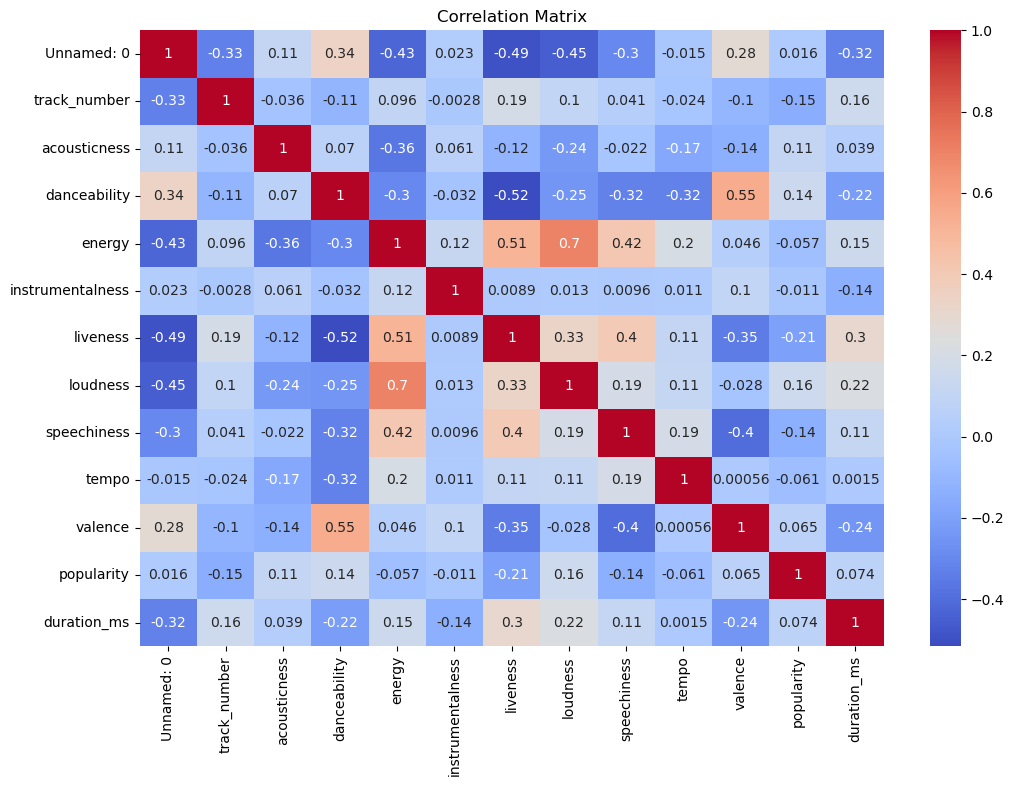

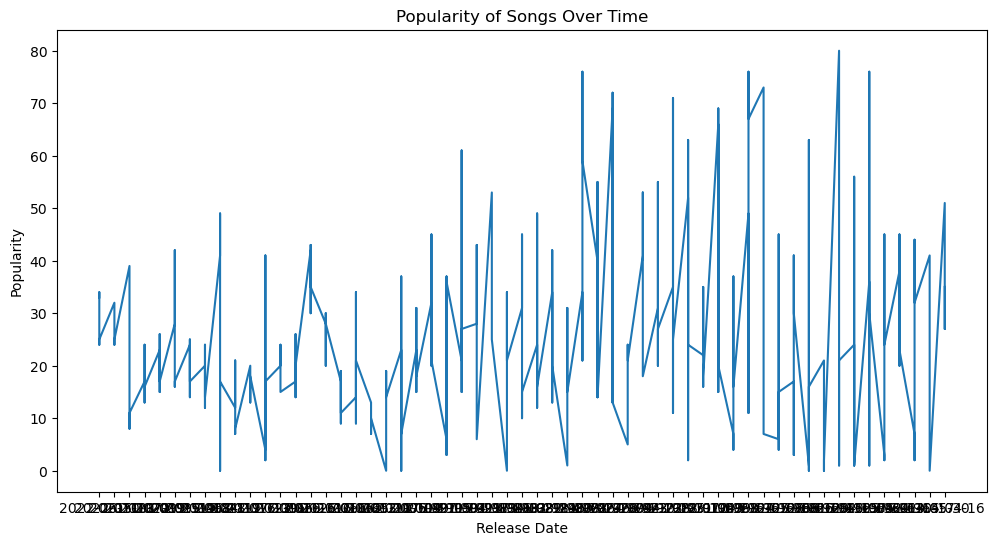

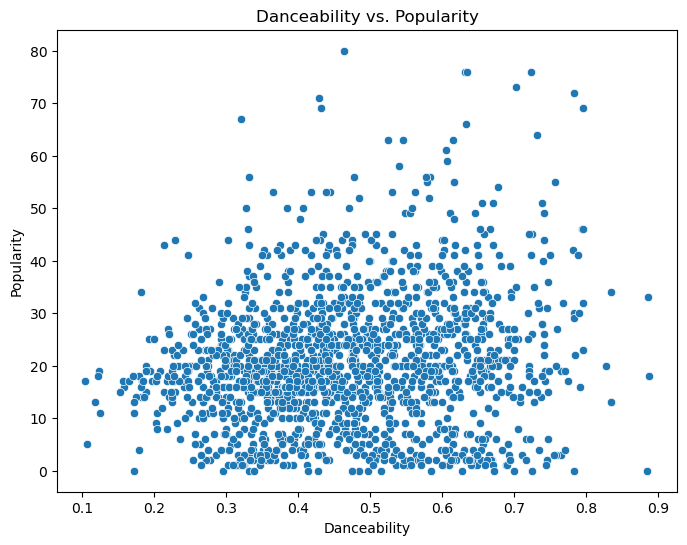

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['release_date'], df['popularity'])
plt.xlabel('Release Date')
plt.ylabel('Popularity')
plt.title('Popularity of Songs Over Time')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Danceability vs. Popularity')
plt.show()


In [15]:
# Comment on the importance of dimensionality reduction techniques- 
# Simplicity is Key: Reduce complexity in data to improve model understanding.
# Faster Processing: Less features mean quicker calculations and less computer power needed.
# Enhanced Understanding: Simplified data allows for clearer patterns and insights.
# Noise Reduction: Helps in filtering out irrelevant information in the data.
# Improved Model Performance: Simplified data often leads to better model performance.

In [ ]:
#Perform Cluster Analysis:
#Identify the right number of clusters
#Use appropriate clustering algorithm
#Define each cluster based on the features


/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/eshaanyadav/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.wa

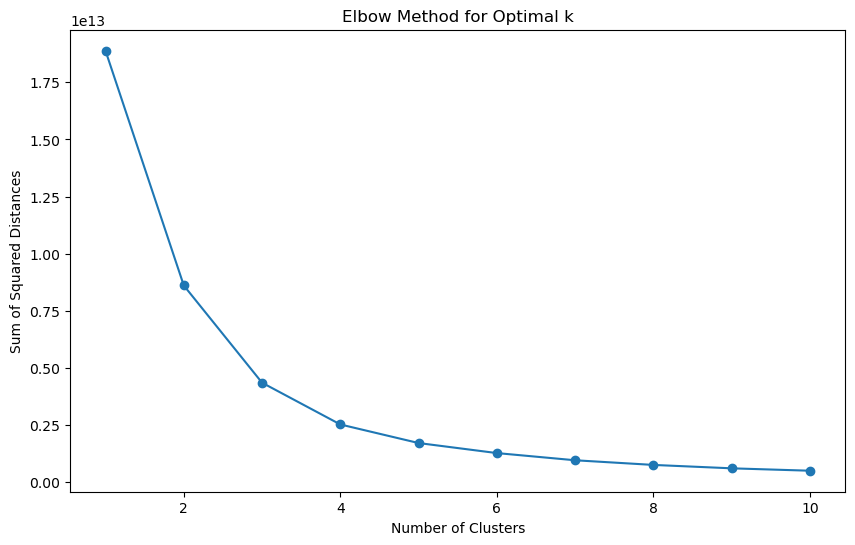

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df.select_dtypes(include=['number']))  
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()


In [25]:
df['cluster'] = kmeans.predict(df.select_dtypes(include=['number']))

cluster_means = df.groupby('cluster').mean()

for cluster_id, cluster_data in cluster_means.iterrows():
    print(f"Cluster {cluster_id}:")
    for feature, value in cluster_data.items():
        print(f"  {feature}: {value}")
    print()

Cluster 0:
  Unnamed: 0: 612.295
  track_number: 10.37
  acousticness: 0.3040532215
  danceability: 0.43705
  energy: 0.7693800000000001
  instrumentalness: 0.11889127145
  liveness: 0.541424
  loudness: -6.611115
  speechiness: 0.0678335
  tempo: 118.71141
  valence: 0.48070549999999995
  popularity: 22.35
  duration_ms: 327708.295

Cluster 1:
  Unnamed: 0: 1143.6980198019803
  track_number: 8.193069306930694
  acousticness: 0.2041395688118812
  danceability: 0.5421237623762376
  energy: 0.7179009900990099
  instrumentalness: 0.2754726820792079
  liveness: 0.31496138613861385
  loudness: -8.551950495049505
  speechiness: 0.05756485148514851
  tempo: 119.06729207920793
  valence: 0.702370297029703
  popularity: 15.910891089108912
  duration_ms: 137362.1683168317

Cluster 2:
  Unnamed: 0: 592.1333333333333
  track_number: 10.166666666666666
  acousticness: 0.19651333333333335
  danceability: 0.3841333333333334
  energy: 0.8231333333333333
  instrumentalness: 0.1759341766666667
  livenes

/var/folders/t5/0nsbwlcs17732cg4y_6c7g6h0000gn/T/ipykernel_50679/2232713760.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cluster_means = df.groupby('cluster').mean()
